## **Import and verification of the dataset structure** 

In [2]:
import sys
sys.path.append("..")

from src.preprocess import (
    load_metadata,
    load_all_texts,
    add_id_to_texts,
    merge_metadata_texts
)

df_meta = load_metadata("../data/raw/archelect_search.csv")
df_texts = load_all_texts("../data/raw/arkindex_archelec/text_files")
df_texts = add_id_to_texts(df_texts)

df_merged = merge_metadata_texts(df_meta, df_texts)

c:\Users\Narji\Documents\Projet NLP\NLP_Project_SpatialAnalysis\notebooks\..\src\preprocess.py:7: DtypeWarning: Columns (0: departement-nom, 1: departement-insee, 2: identifiant de circonscription, 3: pdf, 4: suppleant-nom, 5: suppleant-prenom, 6: suppleant-sexe, 7: suppleant-age, 8: suppleant-age-calcule, 9: suppleant-age-tranche, 10: suppleant-profession, 11: suppleant-mandat-en-cours, 12: suppleant-mandat-passe, 13: suppleant-associations, 14: suppleant-autres-statuts, 15: suppleant-soutien, 16: suppleant-liste, 17: suppleant-decorations) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


In [3]:
df_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 21167 entries, 0 to 21166
Data columns (total 45 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   id                              21167 non-null  str   
 1   date                            21167 non-null  str   
 2   subject                         21167 non-null  str   
 3   title                           21167 non-null  str   
 4   contexte-election               21167 non-null  str   
 5   contexte-tour                   21167 non-null  int64 
 6   cote                            21167 non-null  str   
 7   departement                     21167 non-null  str   
 8   departement-nom                 21167 non-null  str   
 9   departement-insee               21167 non-null  str   
 10  identifiant de circonscription  21167 non-null  object
 11  images                          21156 non-null  str   
 12  pdf                             21151 non-null  str   
 1

In [4]:
df_merged.head()

,id,date,subject,title,contexte-election,contexte-tour,cote,departement,departement-nom,departement-insee,...,suppleant-mandat-en-cours,suppleant-mandat-passe,suppleant-associations,suppleant-autres-statuts,suppleant-soutien,suppleant-liste,suppleant-decorations,zip_file,text_file,text
0,EL065_L_1973_03_001_01_1_PF_01,1973-03-04,Assemblée Nationale;France;Ve République;Élect...,"Élections législatives de 1973, Ain - 01, circ...",législatives,1,EL065,01,Ain,01 - Ain,...,maire,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,non,legislatives.zip,legislatives/EL065_L_1973_03_001_01_1_PF_01.txt,Sciences Po / fonds CEVIPOF\nREPUBLIQUE FRANÇA...
1,EL065_L_1973_03_001_01_1_PF_02,1973-03-04,Élections législatives;Ve République;Assemblée...,"Élections législatives de 1973, Ain - 01, circ...",législatives,1,EL065,01,Ain,01 - Ain,...,conseiller général,non mentionné,non mentionné,non mentionné,Parti socialiste;Mouvement des radicaux de gauche,Union de la gauche socialiste et démocrate,non,legislatives.zip,legislatives/EL065_L_1973_03_001_01_1_PF_02.txt,REPUBLIQUE FRANCAISE - LIBERTE - EGALITE - FRA...
2,EL065_L_1973_03_001_01_1_PF_03,1973-03-04,Assemblée Nationale;Ve République;Élections lé...,"Élections législatives de 1973, Ain - 01, circ...",législatives,1,EL065,01,Ain,01 - Ain,...,non mentionné,non mentionné,non mentionné,non mentionné,non mentionné,Faîtes confiance aux jeunes d'aujourd'hui,non,legislatives.zip,legislatives/EL065_L_1973_03_001_01_1_PF_03.txt,Sciences Po / fonds CEVIPOF\nREPUBLIQUE FRANÇA...
3,EL065_L_1973_03_001_01_1_PF_04,1973-03-04,France;Ve République;Élections législatives;As...,"Élections législatives de 1973, Ain - 01, circ...",législatives,1,EL065,01,Ain,01 - Ain,...,non mentionné,non mentionné,non mentionné,non mentionné,Parti communiste français,Union populaire et victoire du programme commun,oui,legislatives.zip,legislatives/EL065_L_1973_03_001_01_1_PF_04.txt,Sciences Po / fonds CEVIPOF\nREPUBLIQUE FRANÇA...
4,EL065_L_1973_03_001_01_1_PF_05,1973-03-04,Élections législatives;France;Assemblée Nation...,"Élections législatives de 1973, Ain - 01, circ...",législatives,1,EL065,01,Ain,01 - Ain,...,maire,non mentionné,sports et loisirs,résistant,non mentionné,Majorité Ve République,oui,legislatives.zip,legislatives/EL065_L_1973_03_001_01_1_PF_05.txt,Sciences Po / fonds CEVIPOF\nREPUBLIQUE FRANÇA...


In [10]:
df_merged.isna().sum().sort_values(ascending=False)

pdf                               16
titulaire-profession              16
images                            11
suppleant-profession               5
titulaire-associations             2
suppleant-associations             1
title                              0
contexte-tour                      0
cote                               0
contexte-election                  0
subject                            0
date                               0
id                                 0
departement-insee                  0
identifiant de circonscription     0
departement                        0
departement-nom                    0
titulaire-sexe                     0
titulaire-age                      0
titulaire-prenom                   0
ocr_url                            0
titulaire-age-tranche              0
titulaire-mandat-en-cours          0
titulaire-mandat-passe             0
titulaire-autres-statuts           0
titulaire-soutien                  0
titulaire-liste                    0
t

In [13]:
import pandas as pd 

df_merged["year"] = pd.to_datetime(df_merged["date"], errors="coerce").dt.year

## **Data Visualization** 

<Axes: title={'center': 'Number of documents by year'}, xlabel='year'>

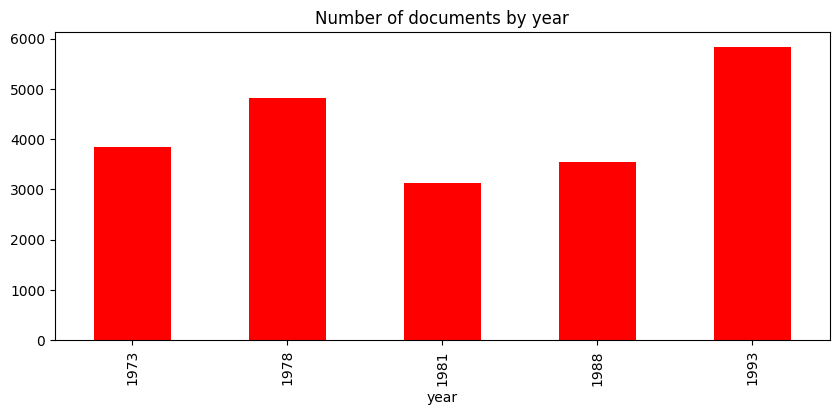

In [16]:
df_merged["year"].value_counts().sort_index().plot(kind="bar", color="red", figsize=(10,4), title="Number of documents by year")

<Axes: title={'center': 'Top 20 departments in the corpus'}, xlabel='departement-nom'>

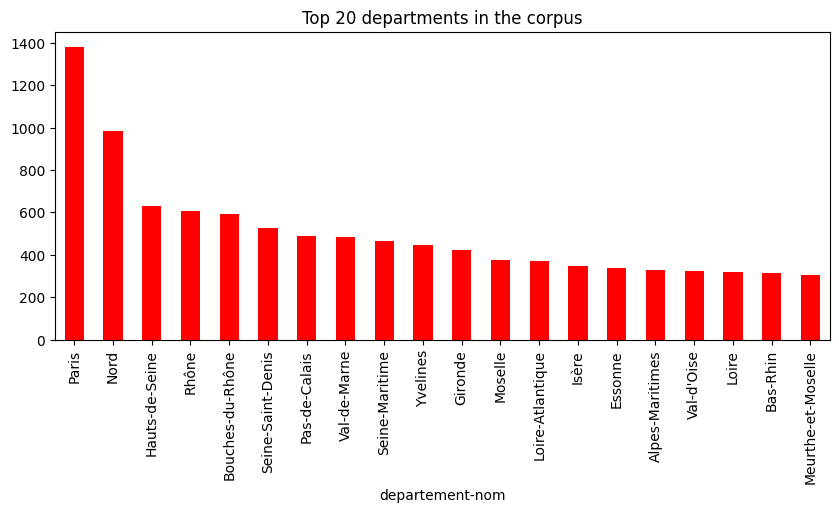

In [23]:
df_merged["departement-nom"].value_counts().head(20).plot(
    kind="bar",
    color="red",
    figsize=(10,4),
    title="Top 20 departments in the corpus"
)

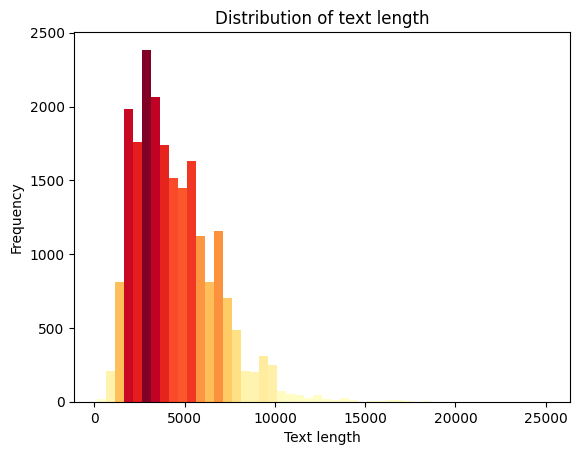

In [26]:
import matplotlib.pyplot as plt
import numpy as np


counts, bins, patches = plt.hist(df_merged["text_length"], bins=50)
norm = plt.Normalize(counts.min(), counts.max())

for count, patch in zip(counts, patches):
    color = plt.cm.YlOrRd(norm(count))
    patch.set_facecolor(color)

plt.title("Distribution of text length")
plt.xlabel("Text length")
plt.ylabel("Frequency")
plt.show()

In [29]:
thresholds = [100, 300, 500, 1000]

for t in thresholds:
    n = (df_merged["text_length"] <= t).sum()
    print(f"Texts with length <= {t}: {n}")

Texts with length <= 100: 0
Texts with length <= 300: 5
Texts with length <= 500: 14
Texts with length <= 1000: 134


<Axes: title={'center': 'Candidate sex distribution'}, xlabel='titulaire-sexe'>

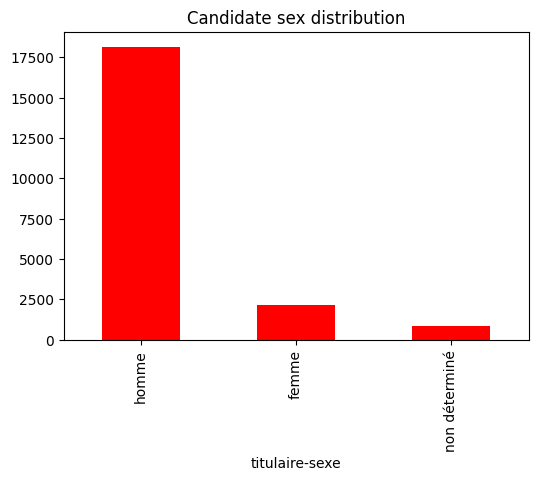

In [30]:
df_merged["titulaire-sexe"].value_counts(dropna=False).plot(
    kind="bar",
    figsize=(6,4),
    color="red",
    title="Candidate sex distribution"
)

<Axes: title={'center': 'Candidate age group distribution'}, xlabel='titulaire-age-tranche'>

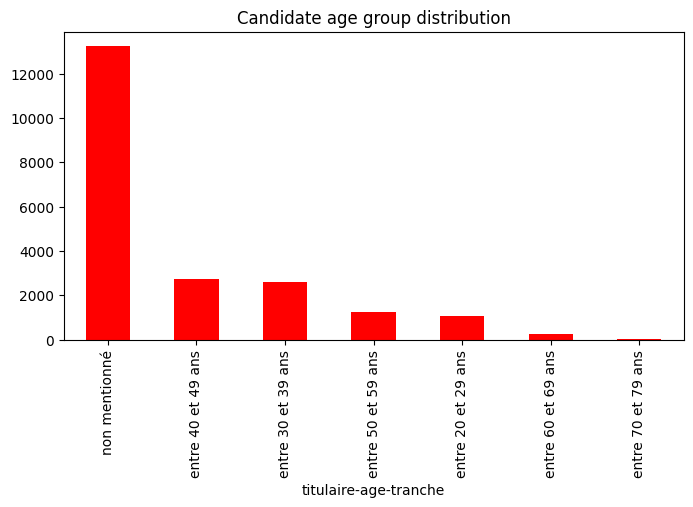

In [32]:
df_merged["titulaire-age-tranche"].value_counts(dropna=False).plot(
    kind="bar",
    figsize=(8,4),
    color="red",
    title="Candidate age group distribution"
)